In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import os
import re



load_dotenv()

True

In [2]:
OUT_MERGED_CSV = f"{os.getenv('PROJECT_ROOT_DIR')}/dataset"

In [3]:
success_csv = f"{OUT_MERGED_CSV}/success_by_dataset_and_version_qwen-7b.csv"
distance_csv= f"{OUT_MERGED_CSV}/lavenshtein_distance_qwen-7b.csv"

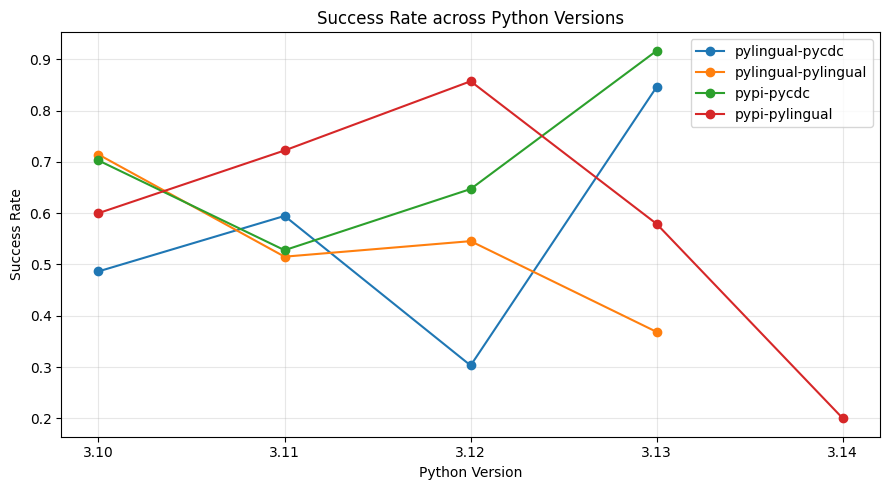

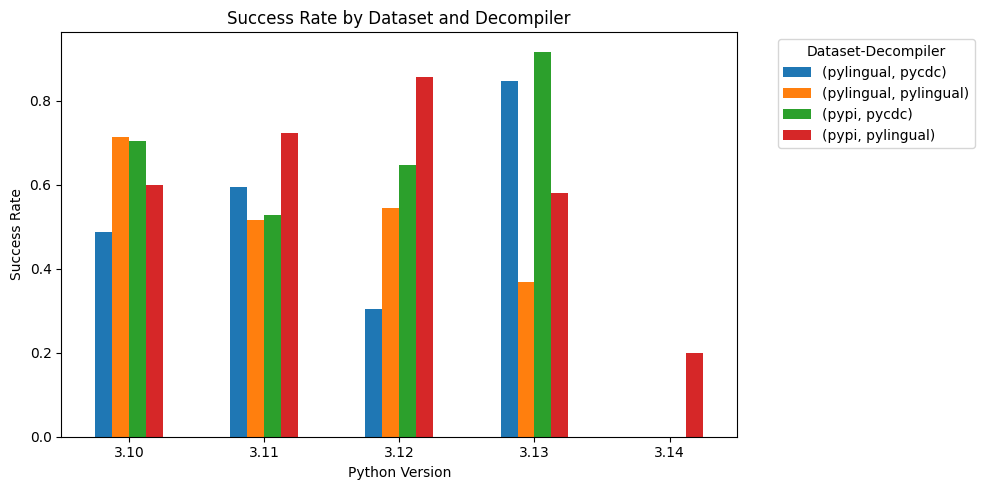

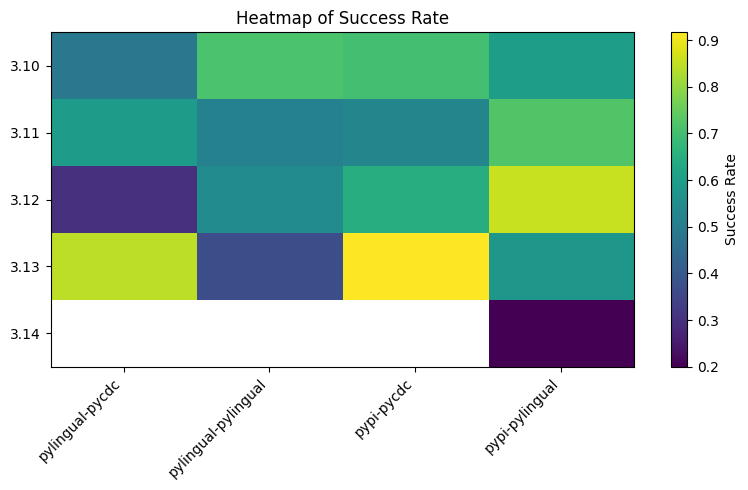

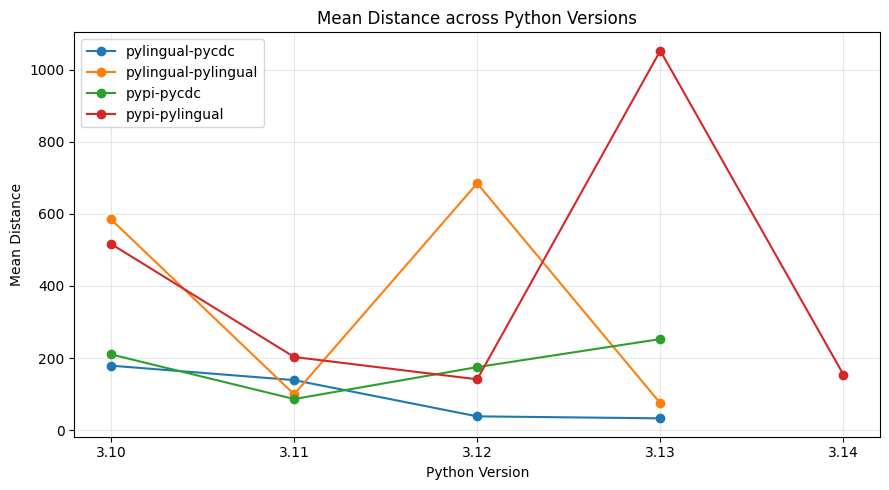

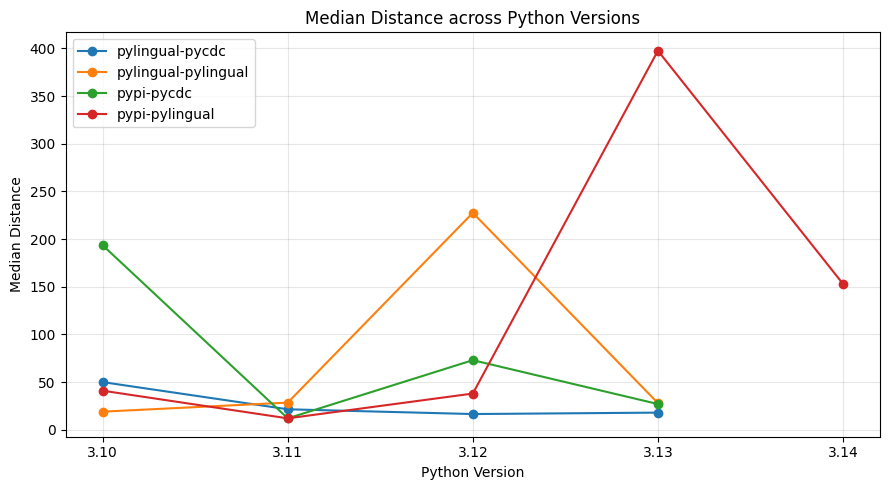

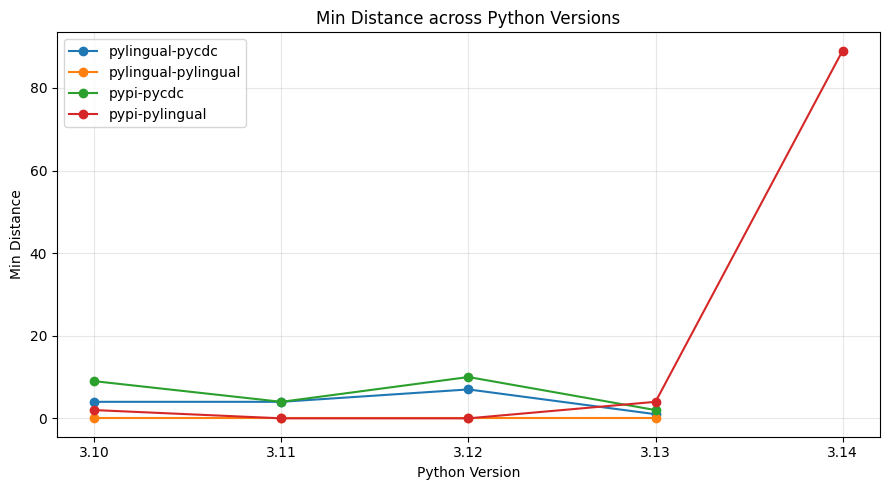

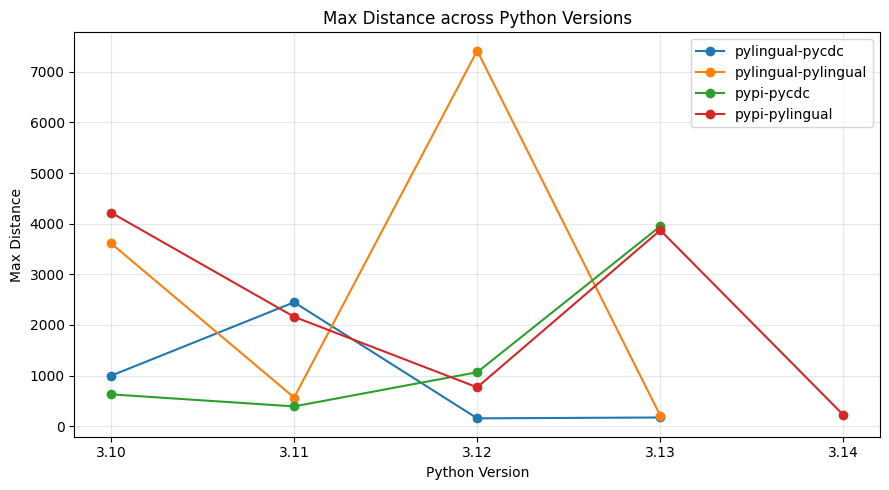

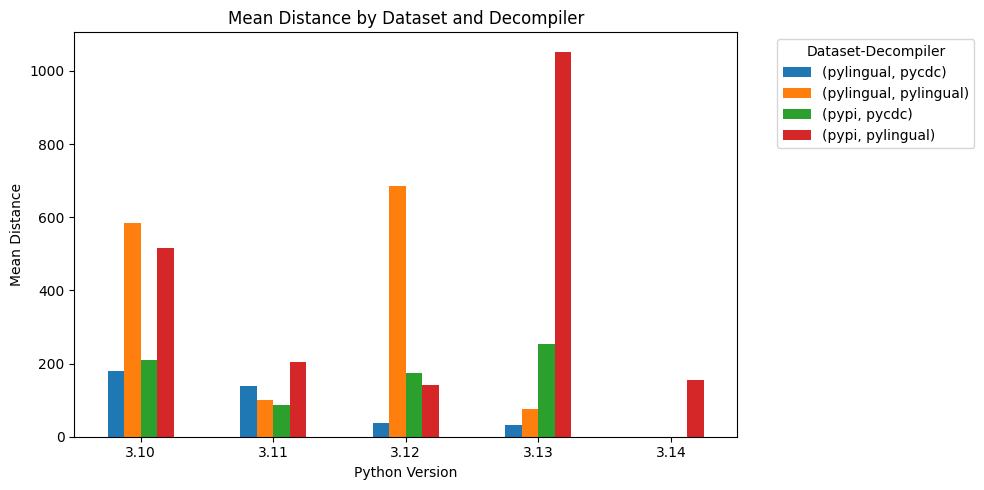

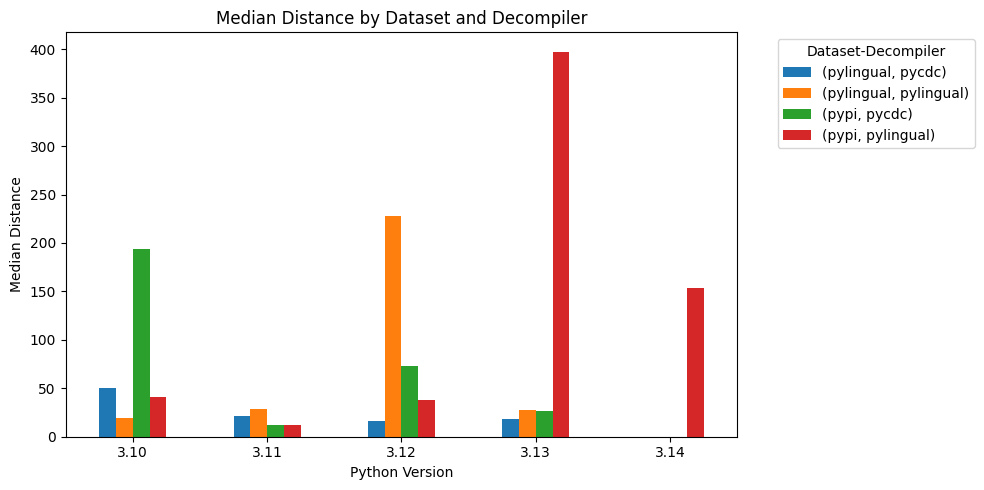

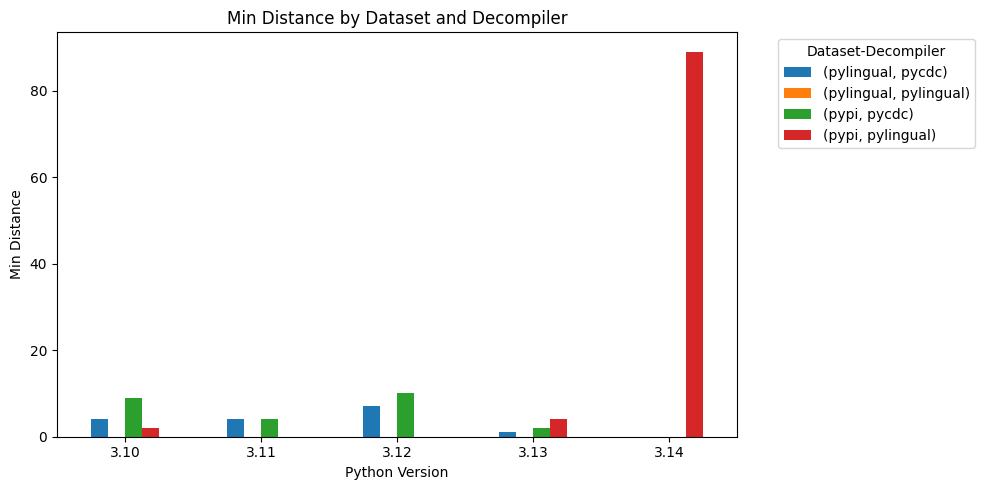

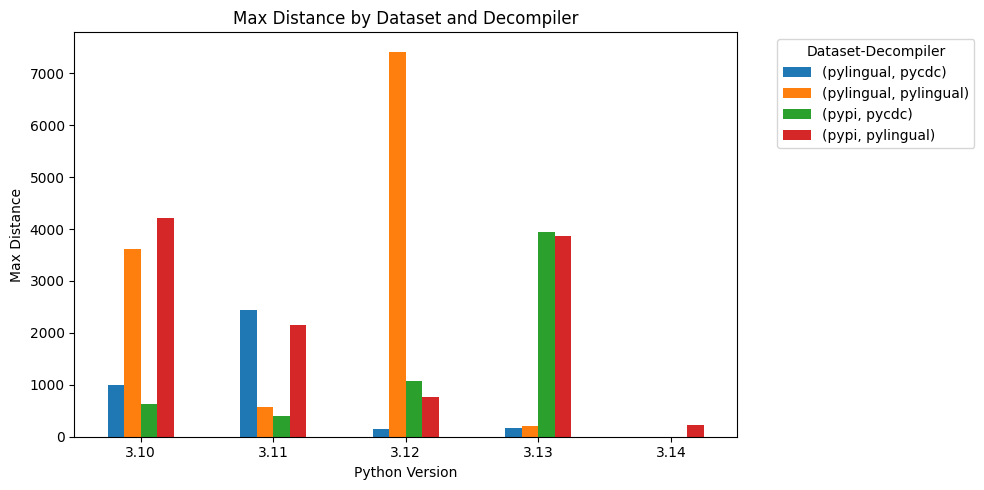

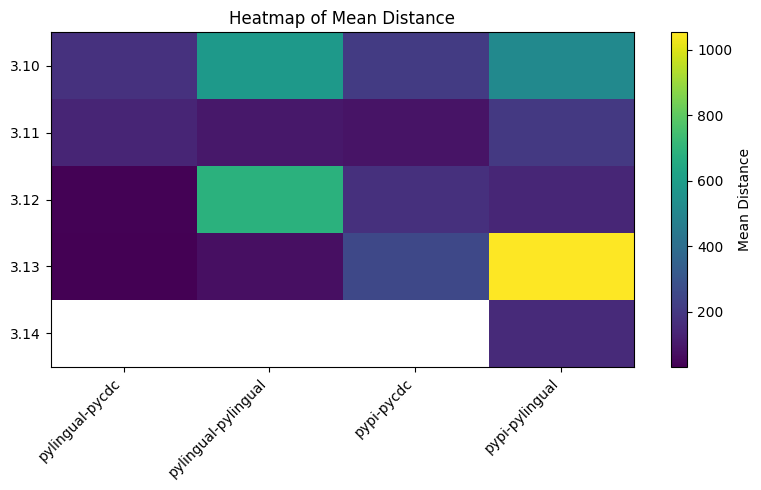

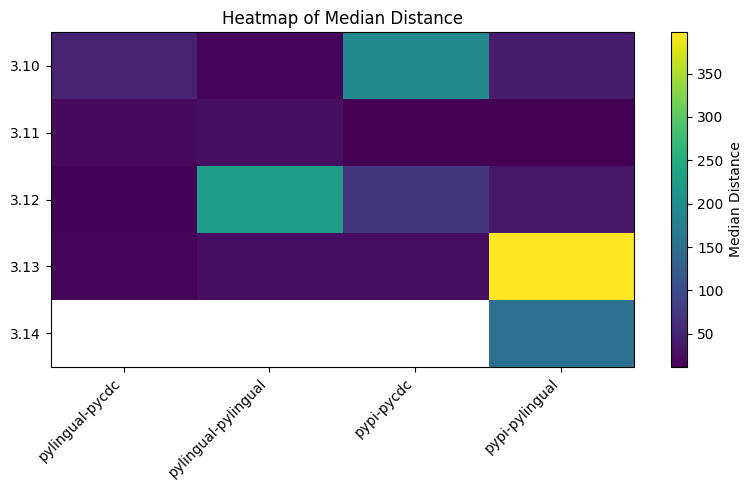

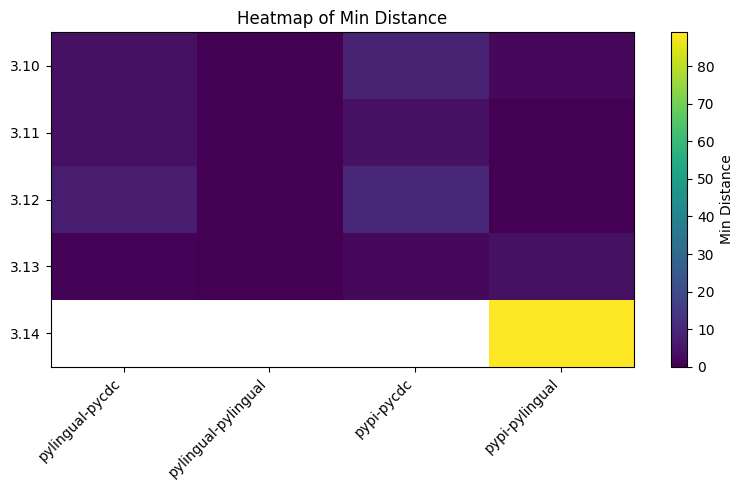

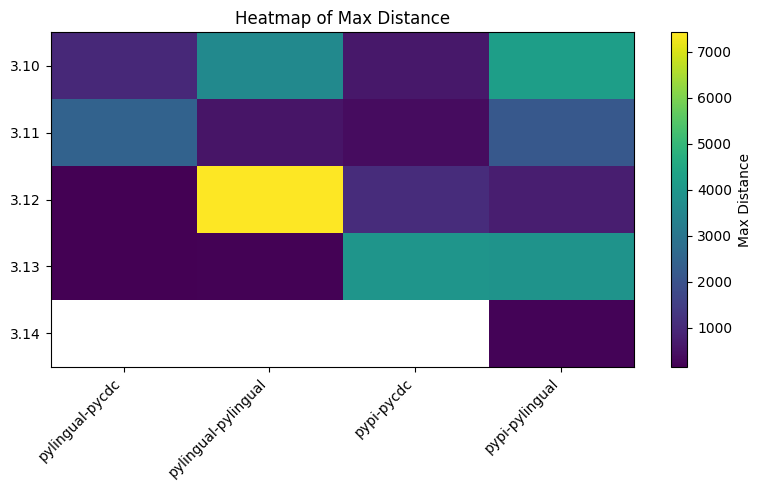

In [4]:
# =====================================================
# Helper: clean bytecode version
# =====================================================
def normalize_version_column(df, col="bytecode_version"):
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].replace({
        "3.1": "3.10",
        3.1: "3.10"
    })
    version_order = ["3.10", "3.11", "3.12", "3.13", "3.14"]
    df[col] = pd.Categorical(df[col], categories=version_order, ordered=True)
    return df.sort_values(col)

# =====================================================
# Read success-rate CSV
# =====================================================
success_df = pd.read_csv(success_csv)

success_df["dataset"] = success_df["dataset"].astype(str).str.strip()
success_df["decompiler"] = success_df["decompiler"].astype(str).str.strip()

for col in ["total_runs", "successful_runs", "success_rate"]:
    success_df[col] = pd.to_numeric(success_df[col], errors="coerce")

success_df = normalize_version_column(success_df)
success_df = success_df.dropna(subset=["dataset", "decompiler", "bytecode_version", "success_rate"])

# =====================================================
# Read distance CSV
# =====================================================
distance_df = pd.read_csv(distance_csv)

distance_df["dataset"] = distance_df["dataset"].astype(str).str.strip()
distance_df["decompiler"] = distance_df["decompiler"].astype(str).str.strip()

for col in ["total_runs", "mean_distance", "median_distance", "min_distance", "max_distance"]:
    distance_df[col] = pd.to_numeric(distance_df[col], errors="coerce")

distance_df = normalize_version_column(distance_df)
distance_df = distance_df.dropna(subset=["dataset", "decompiler", "bytecode_version"])

# =====================================================
# 1. Success rate line plot
# =====================================================
plt.figure(figsize=(9, 5))

for (dataset, decompiler), group in success_df.groupby(["dataset", "decompiler"], observed=True):
    plt.plot(
        group["bytecode_version"],
        group["success_rate"],
        marker="o",
        label=f"{dataset}-{decompiler}"
    )

plt.xlabel("Python Version")
plt.ylabel("Success Rate")
plt.title("Success Rate across Python Versions")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =====================================================
# 2. Success rate grouped bar plot
# =====================================================
success_pivot = success_df.pivot_table(
    index="bytecode_version",
    columns=["dataset", "decompiler"],
    values="success_rate",
    aggfunc="mean",
    observed=True
)

plt.figure(figsize=(10, 5))
success_pivot.plot(kind="bar", ax=plt.gca())
plt.xlabel("Python Version")
plt.ylabel("Success Rate")
plt.title("Success Rate by Dataset and Decompiler")
plt.xticks(rotation=0)
plt.legend(title="Dataset-Decompiler", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# =====================================================
# 3. Success rate heatmap
# =====================================================
plt.figure(figsize=(8, 5))
im = plt.imshow(success_pivot.values, aspect="auto")
plt.colorbar(im, label="Success Rate")
plt.xticks(
    range(len(success_pivot.columns)),
    [f"{a}-{b}" for a, b in success_pivot.columns],
    rotation=45,
    ha="right"
)
plt.yticks(range(len(success_pivot.index)), success_pivot.index)
plt.title("Heatmap of Success Rate")
plt.tight_layout()
plt.show()

# =====================================================
# 4. Distance line plots
# =====================================================
distance_metrics = ["mean_distance", "median_distance", "min_distance", "max_distance"]

for metric in distance_metrics:
    plt.figure(figsize=(9, 5))
    for (dataset, decompiler), group in distance_df.groupby(["dataset", "decompiler"], observed=True):
        plt.plot(
            group["bytecode_version"],
            group[metric],
            marker="o",
            label=f"{dataset}-{decompiler}"
        )
    plt.xlabel("Python Version")
    plt.ylabel(metric.replace("_", " ").title())
    plt.title(f"{metric.replace('_', ' ').title()} across Python Versions")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# =====================================================
# 5. Distance grouped bar plots
# =====================================================
for metric in distance_metrics:
    pivot = distance_df.pivot_table(
        index="bytecode_version",
        columns=["dataset", "decompiler"],
        values=metric,
        aggfunc="mean",
        observed=True
    )

    plt.figure(figsize=(10, 5))
    pivot.plot(kind="bar", ax=plt.gca())
    plt.xlabel("Python Version")
    plt.ylabel(metric.replace("_", " ").title())
    plt.title(f"{metric.replace('_', ' ').title()} by Dataset and Decompiler")
    plt.xticks(rotation=0)
    plt.legend(title="Dataset-Decompiler", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

# =====================================================
# 6. Distance heatmaps
# =====================================================
for metric in distance_metrics:
    pivot = distance_df.pivot_table(
        index="bytecode_version",
        columns=["dataset", "decompiler"],
        values=metric,
        aggfunc="mean",
        observed=True
    )

    plt.figure(figsize=(8, 5))
    im = plt.imshow(pivot.values, aspect="auto")
    plt.colorbar(im, label=metric.replace("_", " ").title())
    plt.xticks(
        range(len(pivot.columns)),
        [f"{a}-{b}" for a, b in pivot.columns],
        rotation=45,
        ha="right"
    )
    plt.yticks(range(len(pivot.index)), pivot.index)
    plt.title(f"Heatmap of {metric.replace('_', ' ').title()}")
    plt.tight_layout()
    plt.show()